# Data Cleaning on Airbnb NYC Dataset

## Objective

The objective of this project is to clean the Airbnb NYC dataset by handling missing values, removing duplicate records, standardizing data formats, and detecting outliers. Data cleaning improves data quality and prepares the dataset for reliable analysis and machine learning applications.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Data Collection

The Airbnb NYC dataset contains information about Airbnb listings such as price, room type, neighbourhood, availability, reviews, and host details.

The dataset is loaded using the pandas library for further exploration and cleaning.

In [ ]:
df = pd.read_csv("/content/AB_NYC_2019.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Explore Dataset


In [ ]:
df.shape
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

# Data Exploration and Cleaning

The dataset is explored to understand its structure, identify missing values, duplicate records, and inconsistent data types before performing the cleaning process.

Missing Values

In [ ]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


# Missing Data Handling

Missing values reduce data quality and may affect analysis results.

The missing values in "reviews_per_month" are replaced using the median value, while missing values in "last_review" are replaced with "Not Available".

In [ ]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(df["reviews_per_month"].median())

df["last_review"] = df["last_review"].fillna("Not Available")

In [ ]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
# Fill missing values with "Unknown"

df["name"] = df["name"].fillna("Unknown")

df["host_name"] = df["host_name"].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


# Duplicate Removal

Duplicate records create redundancy and can produce misleading analytical results.

Duplicate rows are identified and removed to maintain data uniqueness.


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

# Data Integrity

Data integrity ensures that the dataset remains accurate, complete, and consistent throughout the cleaning process.

After cleaning, the dataset is checked again for missing values and duplicate records.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48895 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


# Standardization

Standardization ensures consistency in text formatting and categorical values, making the dataset easier to analyze.

Text columns are converted into a consistent title case format.

In [ ]:
df["neighbourhood_group"] = df["neighbourhood_group"].str.title()

df["room_type"] = df["room_type"].str.title()

# Outlier Detection

Outliers are extreme values that can significantly affect statistical analysis and machine learning models.

A box plot is used to visualize outliers in the price column.

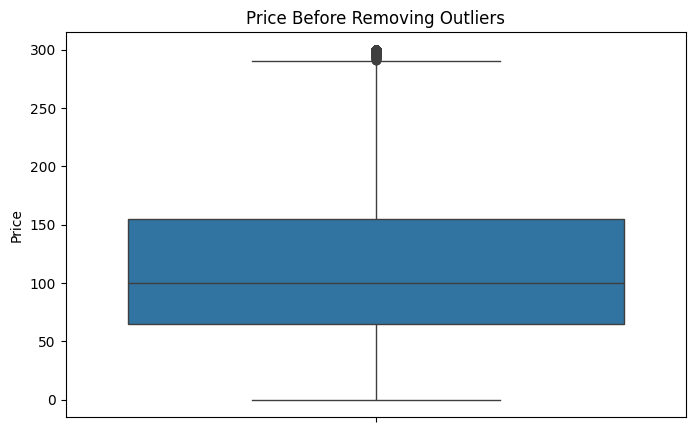

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Save original dataset
df_original = df.copy()

plt.figure(figsize=(8,5))

sns.boxplot(y=df_original["price"])

plt.title("Price Before Removing Outliers")

plt.ylabel("Price")

plt.show()

In [ ]:
# Calculate Quartiles

Q1 = df_original["price"].quantile(0.25)

Q3 = df_original["price"].quantile(0.75)

# Calculate IQR

IQR = Q3 - Q1

# Calculate lower and upper limits

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

# Create cleaned dataset

df_clean = df_original[
    (df_original["price"] >= lower_limit) &
    (df_original["price"] <= upper_limit)
]

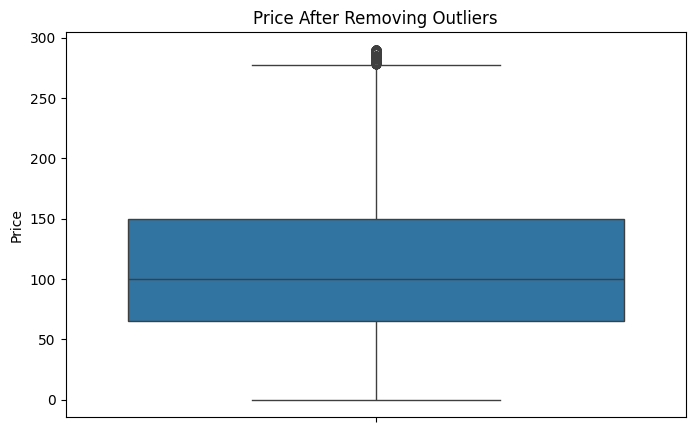

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df_clean["price"])

plt.title("Price After Removing Outliers")

plt.ylabel("Price")

plt.show()

In [ ]:
print("Original Dataset Size :", len(df_original))

print("Dataset Size After Removing Outliers :", len(df_clean))

print("Number of Outliers Removed :", len(df_original) - len(df_clean))

Original Dataset Size : 45538
Dataset Size After Removing Outliers : 44670
Number of Outliers Removed : 868


In [ ]:
# Replace original dataset with cleaned dataset

df = df_clean.copy()

# Visualization

Visualizations help understand the dataset after cleaning by displaying distributions, missing values, and categorical information.

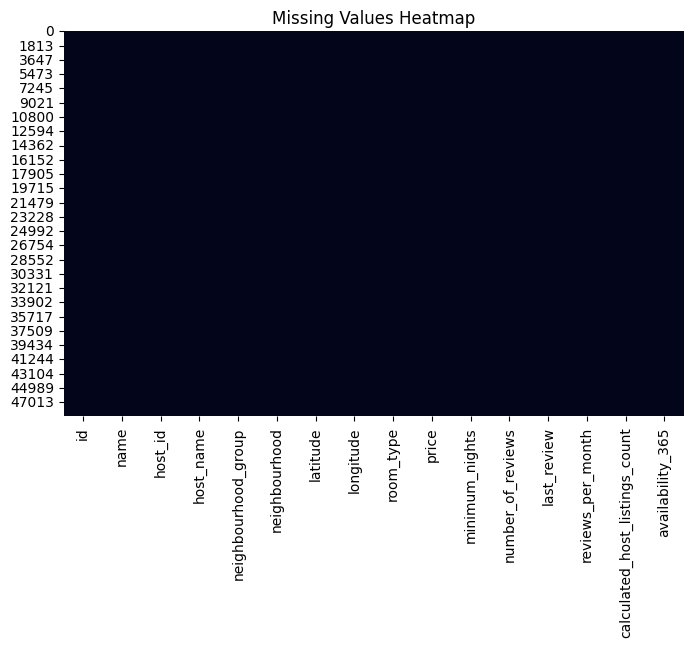

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(df.isnull(),cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

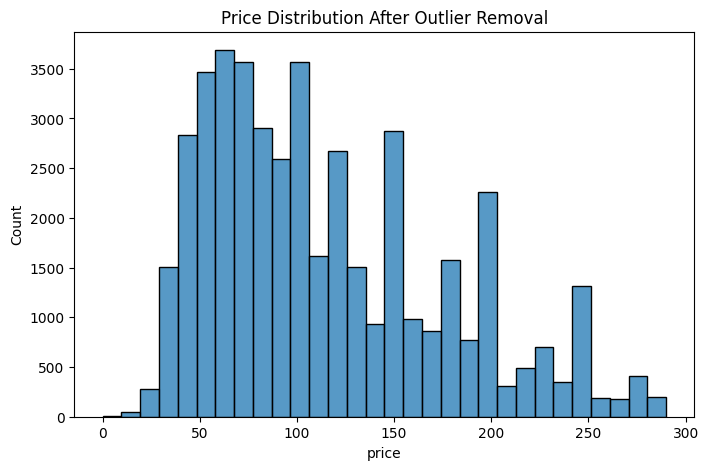

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"],bins=30)

plt.title("Price Distribution After Outlier Removal")

plt.show()

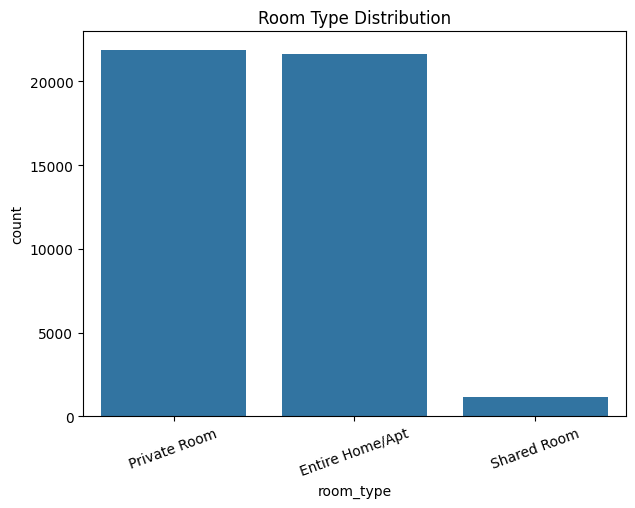

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,x="room_type")

plt.xticks(rotation=20)

plt.title("Room Type Distribution")

plt.show()

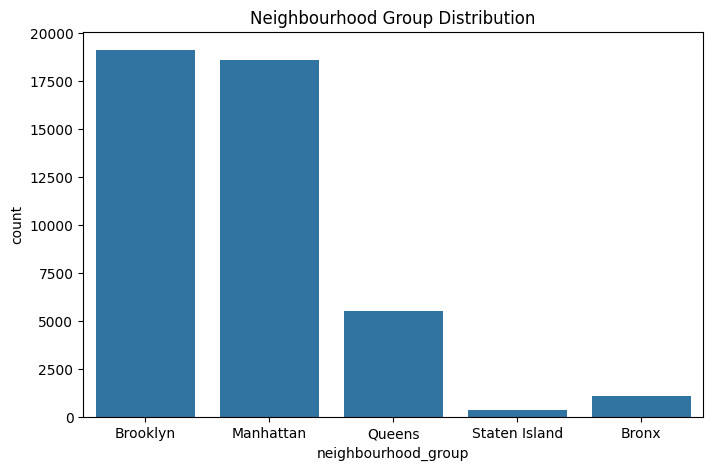

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="neighbourhood_group")

plt.title("Neighbourhood Group Distribution")

plt.show()

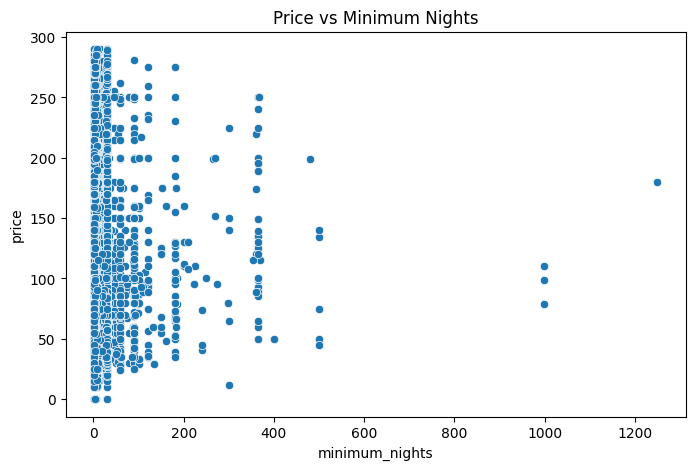

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x="minimum_nights",y="price")

plt.title("Price vs Minimum Nights")

plt.show()

# Insights and Recommendations

## Insights

- Missing values were successfully identified and handled.
- Duplicate records were removed to maintain data quality.
- Data formatting was standardized for consistency.
- Outliers in the price column were detected and removed.
- The cleaned dataset is now more reliable for analysis and predictive modeling.

## Recommendations

- Always validate data before analysis.
- Handle missing values using suitable techniques.
- Remove duplicate records to avoid biased results.
- Standardize categorical variables for consistency.
- Detect and treat outliers before building machine learning models.

# Conclusion

The Airbnb NYC dataset was successfully cleaned by handling missing values, removing duplicate records, standardizing data formats, and detecting outliers. The cleaned dataset is now accurate, consistent, and ready for further analysis and machine learning applications.